In [3]:
from gensim import corpora
import gensim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import CoherenceModel
from tqdm import tqdm


# 加载预训练的中文Word2Vec模型（例如，腾讯的中文词向量）
word_vectors = gensim.models.KeyedVectors.load_word2vec_format('tencent-ailab-embedding-zh-d100-v0.2.0-s/tencent-ailab-embedding-zh-d100-v0.2.0-s.txt', binary=False)
print('加载模型腾讯word2vec成功')

加载模型腾讯word2vec成功


In [4]:
# 创建文档向量
def document2vector(doc,name2idx):
    if isinstance(doc,str):
        doc = doc.split(' ')
    # 移除OOV词汇
    doc = [word for word in doc if word in name2idx.keys() and word in word_vectors.key_to_index]
    doc_embed = [word_vectors[word] for word in doc ]
    
    # assert len(doc) >=1
    mean_vec = np.mean(doc_embed,axis=0)
    return_vector = np.zeros(len(name2idx))
    for word,v in zip(doc,doc_embed):
        sim = cosine_similarity(v.tolist(),mean_vec.tolist())
        index = name2idx[word]
        return_vector[index] = sim
    return return_vector

def tokenize(text):
    return text.split(' ')

def cosine_similarity(a, b):
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)

topic_num = 5
num_words_per_topic = 10 # 每个主题内的关键词数量
with open(f'data/clean_sentence_v2.txt','r',encoding='utf-8') as file:
    documents = [line.strip().split(',')[1] for line in file.readlines()]


In [6]:
# 创建TfidfVectorizer对象
def tokenize(text):
    return text.split(' ')

# 构建此表
vectorizer = TfidfVectorizer(tokenizer=tokenize,max_features=5000)
X = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names()
feature2idx = {feature:idx for idx,feature in enumerate(feature_names)}
print(f'完成词典构建')

doc_embeddings = []
for doc in tqdm(documents):
    doc = doc.split(' ')
    doc_embed = document2vector(doc,feature2idx)
    doc_embeddings.append(doc_embed)

print(f'完成编码')
lda = LatentDirichletAllocation(n_components=topic_num, random_state=2)
W = lda.fit_transform(doc_embeddings)
H = lda.components_


# 打印每个主题的关键词
def print_top_words(model, feature_names, num_words_per_topic):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-num_words_per_topic - 1:-1]]))

print_top_words(lda, feature_names, num_words_per_topic)

完成词典构建


 29%|██████████████████████▎                                                      | 2526/8730 [00:03<00:06, 946.96it/s]D:\Anacoder\lib\site-packages\numpy\core\fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\Anacoder\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
100%|█████████████████████████████████████████████████████████████████████████████| 8730/8730 [00:09<00:00, 932.20it/s]


完成编码
Topic 1:
口感 味道 吃 喝 好吃 新鲜 方便 好喝 营养 口味
Topic 2:
购物 收到 发货 一次 服务态度 好评 宝贝 卖家 下次 特别
Topic 3:
方便 容量 下单 快递 第二天 挺 做工 比较 外观 好看
Topic 4:
吃 一直 品牌 方便 实惠 味道 活动 比较 挺 这款
Topic 5:
舒服 舒适 穿 合适 柔软 材质 面料 设计 颜色 尺码


In [7]:
# 创建字典
id2word = corpora.Dictionary([tokenize(doc) for doc in documents])

# 转换为gensim的corpus格式
gensim_corpus = [id2word.doc2bow(tokenize(doc)) for doc in documents]

# 获取每个主题的前n个词
def get_topic_words(model, feature_names, n_top_words):
    topic_words_probs = []
    for topic in model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        probs = [topic[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        prob_sum = sum(probs)
        topic_words_probs.append([(word ,prob/prob_sum) for word ,prob in zip(top_words,probs)])

    return topic_words_probs

topic_words_probs = get_topic_words(lda, feature_names, num_words_per_topic)

# 计算主题一致性指标
topic_words = []
for item_list in topic_words_probs:
    topic_words.append([item[0] for item in item_list])
    
coherence_model_cv = CoherenceModel(topics=topic_words, texts=[tokenize(doc) for doc in documents], dictionary=id2word, coherence='c_v')
coherence_model_cpmi = CoherenceModel(topics=topic_words, texts=[tokenize(doc) for doc in documents], dictionary=id2word, coherence='c_npmi')
coherence_model_uci = CoherenceModel(topics=topic_words, texts=[tokenize(doc) for doc in documents], dictionary=id2word, coherence='c_uci')
coherence_model_umass = CoherenceModel(topics=topic_words, corpus=gensim_corpus, dictionary=id2word, coherence='u_mass')

# 打印结果
print(f"C_v coherence: {coherence_model_cv.get_coherence()}")
print(f"C_pmi coherence: {coherence_model_cpmi.get_coherence()}")
print(f"C_uci coherence: {coherence_model_uci.get_coherence()}")
print(f"U_mass coherence: {coherence_model_umass.get_coherence()}")

C_v coherence: 0.611597205533166
C_pmi coherence: 0.09585403607326226
C_uci coherence: 0.5193102103798115
U_mass coherence: -2.2057546236062207


In [8]:
'''主题间的差异性——Jaccard相似度,越低越好'''

# 计算主题词之间的重叠度，重叠度越低，表示主题之间的差异性越大

def jaccard_similarity(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    return len(s1.intersection(s2)) / len(s1.union(s2))

# 假设lda_model是训练好的LDA模型
jaccard_scores = []
for i in range(len(topic_words_probs)):
    for j in range(i + 1, len(topic_words_probs)):
        words_i = [word for word, prob in topic_words_probs[i]]
        words_j = [word for word, prob in topic_words_probs[j]]
        jaccard_scores.append(jaccard_similarity(words_i, words_j))

avg_jaccard_score = sum(jaccard_scores) / len(jaccard_scores)
print(f'Average Jaccard similarity: {avg_jaccard_score}')

# 计算主题分布之间的KL散度来衡量它们的差异性。KL散度越大，表示主题之间的差异性越大。
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
# 假设word_vectors是预训练的词向量模型
def get_topic_vector(topic, word_vectors):
    vector = np.zeros(word_vectors.vector_size)
    for word, prob in topic:
        if word in word_vectors:
            vector += prob * word_vectors[word]
    return vector

# 获取每个主题的向量表示
topic_vectors = []
for topic in topic_words_probs:
    topic_vector = get_topic_vector(topic, word_vectors)
    topic_vectors.append(topic_vector)

# 计算余弦相似度
cosine_similarities = cosine_similarity(topic_vectors)
avg_cosine_similarity = np.mean(cosine_similarities[np.triu_indices(len(topic_vectors), k=1)])
print(f'Average cosine similarity: {avg_cosine_similarity}') # 越低越好，接近0最好


Average Jaccard similarity: 0.04055727554179567
Average cosine similarity: 0.7264239780307518


num of topic :  5 5


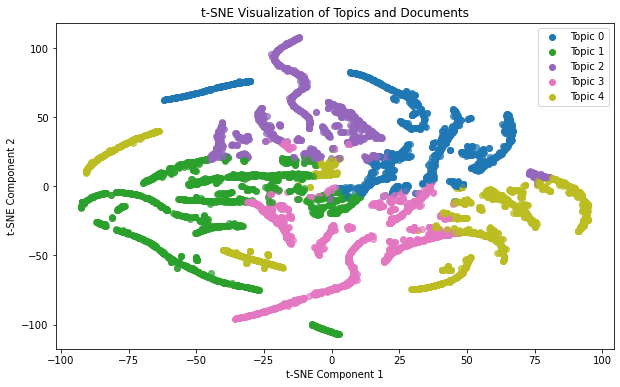

In [9]:
import gensim
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 定义函数获取主题向量
def get_topic_vector(topic, word_vectors):
    vector = np.zeros(word_vectors.vector_size)
    word_count = 0
    for word, prob in topic:
        if word in word_vectors:
            vector += prob * word_vectors[word]
            word_count += 1
    if word_count > 0:
        vector /= word_count
    return vector

# 获取每个主题的向量表示
topic_vectors = []
for topic in topic_words_probs:
    topic_vector = get_topic_vector(topic, word_vectors)
    topic_vectors.append(topic_vector)

print('num of topic : ',len(topic_vectors),topic_num)

# 获取每个文档所属的主题
document_vectors = []
document_labels = []  # 存储文档所属主题
for doc_id, tpoics_prob in enumerate(W):
    tpoics_prob = tpoics_prob / sum(tpoics_prob)
    doc_vector = np.zeros(word_vectors.vector_size)
    topic_index = tpoics_prob.argsort()[::-1]
    max_topic = topic_index[0]
    document_labels.append(max_topic)  # 记录文档所属的主题
    for t_num, prob in enumerate(tpoics_prob):
        doc_vector += prob * topic_vectors[t_num]
    document_vectors.append(doc_vector)

# 将主题向量和文档向量组合在一起
all_vectors = np.vstack((topic_vectors, document_vectors))
# 使用t-SNE降维
tsne_model = TSNE(n_components=2, random_state=1)
tsne_vectors = tsne_model.fit_transform(all_vectors)
# 分离t-SNE降维结果中的主题和文档向量
tsne_topic_vectors = tsne_vectors[:len(topic_vectors)]
tsne_document_vectors = tsne_vectors[len(topic_vectors):]
# 可视化
plt.figure(figsize=(10, 6))
# 绘制文档
for i, label in enumerate(document_labels):
    color = plt.cm.get_cmap('tab10')(label / topic_num)  # 使用不同颜色代表不同主题
    plt.scatter(tsne_document_vectors[i, 0], tsne_document_vectors[i, 1], color=color, alpha=0.7)
# 绘制主题
for i, label in enumerate(range(topic_num)):
    color = plt.cm.get_cmap('tab10')(label / topic_num)  # 使用不同颜色代表不同主题
    plt.scatter(tsne_topic_vectors[i, 0], tsne_topic_vectors[i, 1], color=color, label=f'Topic {label}')
    # plt.annotate(f'Topic {label}', (tsne_topic_vectors[i, 0], tsne_topic_vectors[i, 1]), textcoords="offset points", xytext=(0, 10), ha='center', color='black')
plt.title("t-SNE Visualization of Topics and Documents")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

In [ ]:
# 计算组内的文本相似度
documents_dict = {}

# 定义函数获取主题向量
def get_doc_vecotr(sents, word_vectors):
    vector = np.zeros(word_vectors.vector_size)
    word_count = 0
    for word in sents:
        if word in word_vectors:
            vector +=  word_vectors[word]
            word_count += 1
    if word_count > 0:
        vector /= word_count
    return vector

for doc_idx , (doc_label ,doc_sent) in enumerate(zip(document_labels,documents)):
    tmp = documents_dict.get(doc_label,[])
    doc_vec = get_doc_vecotr(doc_sent.split(' '),word_vectors)
    tmp.append(doc_vec)
    documents_dict[doc_label] = tmp

doc_vecotors = []
for label , item in documents_dict.items():
    all_vec= np.array(item)
    doc_vecotors.append(np.mean(all_vec,axis=0))

cosine_similarities = cosine_similarity(doc_vecotors)
avg_cosine_similarity = np.mean(cosine_similarities[np.triu_indices(len(doc_vecotors), k=1)])
print(f'Doc across different topics : {avg_cosine_similarity}') # 越低越好，接近0最好


cos_list = []
for label , item in documents_dict.items():
    item = [np.array(i) for i in item]
    cosine_similarities = cosine_similarity(item)
    avg_cosine_similarity = np.mean(cosine_similarities[np.triu_indices(len(item), k=1)])
    cos_list.append(avg_cosine_similarity)
print(f'Doc in single topic : {sum(cos_list)/len(cos_list)}') # 越高越好